## Primer prompt de prueba
Se va a hacer un análisis con Olivetti faces

Explicación paso a paso del proceso de Dictionary Learning con scikit-learn

En primer lugar se carga un conjunto de datos de imágenes disponible directamente en la API de scikit-learn. En este caso se utiliza el dataset fetch_olivetti_faces, que contiene 400 imágenes en escala de grises de tamaño 64×64 píxeles. Estas imágenes representan distintos rostros y son un conjunto clásico en tareas de procesamiento de imagen y aprendizaje no supervisado. No se realiza ningún redimensionado de las imágenes, respetando su tamaño original.

A continuación se extraen parches pequeños de cada imagen utilizando la función extract_patches_2d. Un parche es una subimagen local, en este caso de tamaño 16×16 píxeles. De cada imagen se extraen múltiples parches aleatorios, lo que permite obtener miles de ejemplos locales que capturan estructuras simples como bordes, texturas y patrones básicos. Estos parches constituyen los datos de entrada reales para el aprendizaje del diccionario.

Una vez extraídos, cada parche se transforma en un vector unidimensional de longitud 256 (porque 16×16 = 256). Esto es necesario porque los algoritmos de scikit-learn trabajan con matrices de datos donde cada fila representa una muestra y cada columna una característica.

Antes de aprender el diccionario, los parches se normalizan utilizando StandardScaler. Esta normalización centra los datos en media cero y varianza unitaria, lo cual es importante para que el algoritmo no favorezca píxeles con mayor escala de valores y para mejorar la estabilidad numérica del proceso de optimización.

Posteriormente se aplica el algoritmo de Dictionary Learning mediante la clase MiniBatchDictionaryLearning. Este método busca aprender un conjunto de vectores base, llamados átomos del diccionario, de tal forma que cada parche pueda representarse como una combinación lineal de unos pocos de estos átomos. Se especifica el número de componentes del diccionario, por ejemplo 100, que corresponde al número de patrones básicos que se desean aprender. El parámetro alpha controla el nivel de esparsidad, forzando a que cada parche se represente usando solo unos pocos átomos.

El algoritmo se entrena ajustando el diccionario a todos los parches extraídos. Como resultado se obtiene una matriz donde cada fila corresponde a un átomo del diccionario, es decir, un patrón visual típico de tamaño 16×16 píxeles.

Después de aprender el diccionario, se calcula la representación dispersa de cada parche mediante el método transform. Esto produce una matriz de coeficientes donde cada fila contiene los pesos con los que se combinan los átomos del diccionario para reconstruir un parche concreto. La mayoría de estos coeficientes son cercanos a cero, lo que confirma la propiedad de esparsidad.

Finalmente, los átomos aprendidos se visualizan reordenando cada vector de 256 elementos en una imagen de 16×16 píxeles. Estas imágenes suelen mostrar estructuras similares a bordes orientados, manchas de intensidad o pequeñas texturas, que son los bloques básicos con los que se pueden reconstruir los parches originales.

En conjunto, este procedimiento permite aprender automáticamente una base eficiente de patrones visuales a partir de datos sin etiquetar, logrando una representación compacta y esparsa de las imágenes, lo cual es útil en compresión, eliminación de ruido y análisis de características.

Dataset shape: (400, 64, 64)
Train images: (320, 64, 64)
Test images: (80, 64, 64)
Number of training patches: 16000
Dictionary shape: (100, 256)
Reconstruction MSE (1 image): 0.0014803459661483507


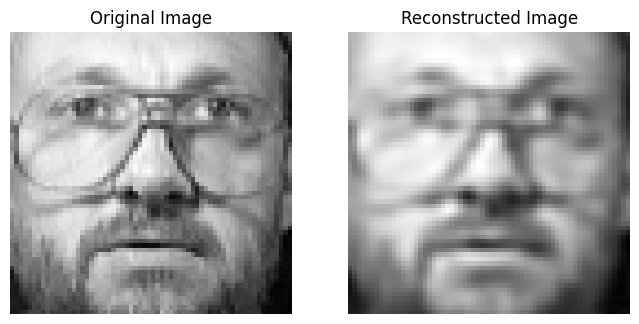

Calculando MSE promedio usando 100 parches aleatorios por imagen...
Average test MSE (estimated): 0.0011776400191592985


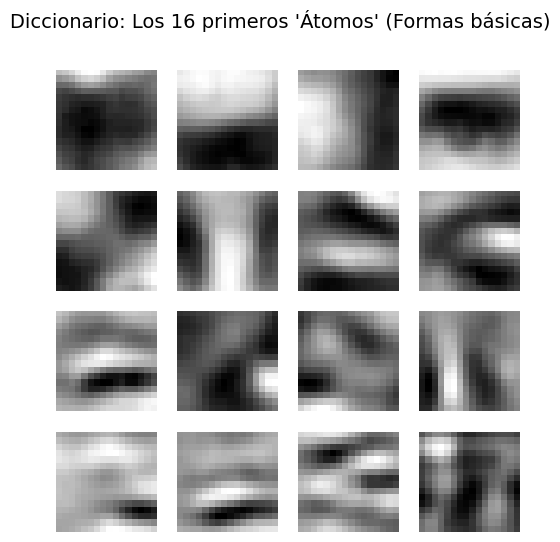

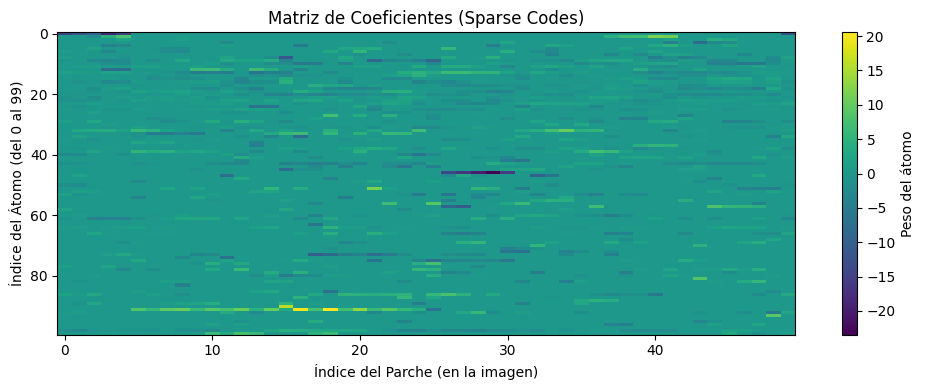


Interpretación:
- Los Átomos son las formas 'maestras' aprendidas.
- La Matriz de Coeficientes muestra qué átomos se activan para cada parte de la cara.
- Las zonas oscuras en la matriz significan 'peso cero' (Sparse), lo que hace eficiente al modelo.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.feature_extraction.image import extract_patches_2d
from sklearn.feature_extraction.image import reconstruct_from_patches_2d
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------
# 1) LOAD IMAGE DATASET
# ------------------------------------------------------

dataset = fetch_olivetti_faces()
images = dataset.images  # (400, 64, 64)

print("Dataset shape:", images.shape)

# ------------------------------------------------------
# 2) TRAIN / TEST SPLIT
# ------------------------------------------------------

train_images, test_images = train_test_split(
    images, test_size=0.2, random_state=0
)

print("Train images:", train_images.shape)
print("Test images:", test_images.shape)

# ------------------------------------------------------
# 3) EXTRACT PATCHES FROM TRAIN SET
# ------------------------------------------------------

patch_size = (16, 16)

patches = []

for img in train_images:
    p = extract_patches_2d(img, patch_size, max_patches=50, random_state=0)
    patches.append(p)

patches = np.concatenate(patches, axis=0)

print("Number of training patches:", patches.shape[0])

# Flatten patches
patches = patches.reshape(patches.shape[0], -1)

# Normalize
scaler = StandardScaler(with_mean=True, with_std=True)
patches = scaler.fit_transform(patches)

# ------------------------------------------------------
# 4) LEARN DICTIONARY (TRAINING)
# ------------------------------------------------------

n_components = 100

dict_learner = MiniBatchDictionaryLearning(
    n_components=n_components,
    alpha=1,
    batch_size=256,
    random_state=0
)

dictionary = dict_learner.fit(patches).components_

print("Dictionary shape:", dictionary.shape)

# ------------------------------------------------------
# 5) TEST: RECONSTRUCT ONE TEST IMAGE
# ------------------------------------------------------

test_image = test_images[0]

# Extract ALL patches from test image
test_patches = extract_patches_2d(test_image, patch_size)
n_test_patches = test_patches.shape[0]

# Flatten
test_patches_flat = test_patches.reshape(n_test_patches, -1)

# Normalize with TRAIN scaler
test_patches_flat = scaler.transform(test_patches_flat)

# Sparse coding
test_codes = dict_learner.transform(test_patches_flat)

# Reconstruct patches
reconstructed_patches = np.dot(test_codes, dictionary)

# Undo normalization
reconstructed_patches = scaler.inverse_transform(reconstructed_patches)

# Reshape to 16x16
reconstructed_patches = reconstructed_patches.reshape(
    n_test_patches, patch_size[0], patch_size[1]
)

# Reconstruct full image
reconstructed_image = reconstruct_from_patches_2d(
    reconstructed_patches, test_image.shape
)

# ------------------------------------------------------
# 6) COMPUTE RECONSTRUCTION ERROR
# ------------------------------------------------------

mse = mean_squared_error(test_image, reconstructed_image)
print("Reconstruction MSE (1 image):", mse)

# ------------------------------------------------------
# 7) VISUAL COMPARISON
# ------------------------------------------------------

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(test_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed_image, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")

plt.show()

# ------------------------------------------------------
# 8) OPTIMIZADO: ERROR PROMEDIO CON MUESTREO ALEATORIO
# ------------------------------------------------------

errors = []
max_p = 100  # Reducimos de 2,401 a solo 100 parches por imagen

print(f"Calculando MSE promedio usando {max_p} parches aleatorios por imagen...")

for img in test_images:
    # Solo extraemos una muestra aleatoria (mucho más rápido)
    patches = extract_patches_2d(img, patch_size, max_patches=max_p, random_state=0)
    
    # El resto del proceso es igual, pero con 24 veces menos datos
    n_p = patches.shape[0]
    patches_flat = patches.reshape(n_p, -1)
    patches_flat = scaler.transform(patches_flat)

    codes = dict_learner.transform(patches_flat)
    rec_patches_flat = np.dot(codes, dictionary)
    rec_patches_flat = scaler.inverse_transform(rec_patches_flat)

    # Para calcular el MSE de parches individuales vs originales
    # No necesitamos reconstruir la imagen completa (reconstruct_from_patches_2d)
    # porque ya tenemos los parches originales para comparar.
    err = mean_squared_error(patches.reshape(n_p, -1), rec_patches_flat)
    errors.append(err)

print("Average test MSE (estimated):", np.mean(errors))
# ------------------------------------------------------
# 9) VISUALIZACIÓN DE ÁTOMOS Y COEFICIENTES (AÑADIDO)
# ------------------------------------------------------

# A. Visualizar los primeros 16 "Átomos" del Diccionario
plt.figure(figsize=(6, 6))
plt.suptitle("Diccionario: Los 16 primeros 'Átomos' (Formas básicas)", fontsize=14)
for i in range(16):
    plt.subplot(4, 4, i + 1)
    # Recordamos que cada átomo es un vector de 256, lo volvemos a hacer 16x16
    plt.imshow(dictionary[i].reshape(patch_size), cmap="gray")
    plt.axis("off")
plt.show()

# B. Visualizar la Matriz de Coeficientes de la reconstrucción anterior
# Tomamos los coeficientes de los primeros 50 parches de la imagen de test
plt.figure(figsize=(10, 4))
plt.imshow(test_codes[:50].T, aspect='auto', cmap='viridis')
plt.colorbar(label="Peso del átomo")
plt.title("Matriz de Coeficientes (Sparse Codes)")
plt.xlabel("Índice del Parche (en la imagen)")
plt.ylabel("Índice del Átomo (del 0 al 99)")
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Los Átomos son las formas 'maestras' aprendidas.")
print("- La Matriz de Coeficientes muestra qué átomos se activan para cada parte de la cara.")
print("- Las zonas oscuras en la matriz significan 'peso cero' (Sparse), lo que hace eficiente al modelo.")